# FFNN with Pretrained GloVe 6B 100d - Combined Data

This notebook trains a FFNN to classify a news article into one of five bias labels using averaged GloVe embeddings to represent each news article with an augmented data set that includes both the original kaggle set and the data from our scrappers. 

## Import

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import cycle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from skorch import NeuralNetClassifier

# Device setup
if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

glove_file = 'glove.6B/glove.6B.100d.txt'
if not os.path.exists(glove_file):
    raise FileNotFoundError(f"{glove_file} not found. Please download it from https://nlp.stanford.edu/projects/glove/ and place it in your working directory.")

In [2]:
# Load preprocessed data
train = pd.read_csv('data/combined_train_preprocessed.csv')
test = pd.read_csv('data/combined_test_preprocessed.csv')

train['cleaned_text'] = train['cleaned_text'].astype(str)
test['cleaned_text'] = test['cleaned_text'].astype(str)

# Encode labels
y_train_raw = train['Bias']
y_test_raw = test['Bias']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

## Weighted FFNN with GloVe

In [3]:
# Tokenization
def tokenize(text):
    return text.split()

train_tokens = [tokenize(text) for text in train['cleaned_text']]
test_tokens = [tokenize(text) for text in test['cleaned_text']]

In [4]:
# Load GloVe embeddings
def load_glove_embeddings(glove_file):
    embeddings = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vec = np.array(parts[1:], dtype=np.float32)
            embeddings[word] = vec
    return embeddings

glove_embeddings = load_glove_embeddings(glove_file)

In [5]:
# Create document embeddings by averaging word vectors
def document_embedding(tokens_list, embeddings, embedding_dim=100):
    doc_embeds = np.zeros((len(tokens_list), embedding_dim))
    for i, tokens in enumerate(tokens_list):
        vectors = [embeddings[token] for token in tokens if token in embeddings]
        if vectors:
            doc_embeds[i] = np.mean(vectors, axis=0)
    return doc_embeds

X_train = document_embedding(train_tokens, glove_embeddings)
X_test = document_embedding(test_tokens, glove_embeddings)

In [6]:
# FFNN Model
# We chose a 3 layer model as LSTM has 3 gates
class FFNN(nn.Module):
    def __init__(self, input_dim, dropout, hidden_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
output_dim = len(label_encoder.classes_)

In [7]:
# Class weights
class_counts = np.bincount(y_train)
class_counts = torch.tensor(class_counts, dtype=torch.float)
weights = 1. / class_counts
weights = weights / weights.sum()

## Model Training

In [8]:
# Wrap model for skorch
from skorch.callbacks import LRScheduler, EarlyStopping, EpochScoring
from torch.optim.lr_scheduler import ReduceLROnPlateau

net = NeuralNetClassifier(
    module=FFNN,
    module__input_dim=input_dim,
    module__hidden_dim=512,  
    module__output_dim=output_dim,
    module__dropout=0.5,  
    optimizer=torch.optim.Adam,
    criterion=nn.CrossEntropyLoss(weight=weights),
    lr=0.0005,  
    batch_size=16,
    max_epochs=15, 
    device=device,
    callbacks=[
        EpochScoring(scoring='f1_weighted', name='train_f1', lower_is_better=False, on_train=True),
        EpochScoring(scoring='accuracy', name='train_acc', lower_is_better=False, on_train=True),
        
        EpochScoring(scoring='f1_weighted', name='valid_f1', lower_is_better=False),
        EpochScoring(scoring='accuracy', name='valid_acc', lower_is_better=False),

        LRScheduler(policy=ReduceLROnPlateau,
                   monitor='valid_f1',  
                   factor=0.3,  
                   patience=3,  
                   verbose=True),
        EarlyStopping(monitor='valid_f1', patience=8, lower_is_better=False),  # Best patience from grid search
    ]
)

In [9]:
net.fit(X_train.astype(np.float32), y_train)

/Users/foongming/.pyenv/versions/3.12.3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  epoch    train_acc    train_f1    train_loss    valid_acc    valid_f1    valid_loss      lr     dur
-------  -----------  ----------  ------------  -----------  ----------  ------------  ------  ------
      1       0.4398      0.3190        1.6045       0.1516      0.0621        1.6050  0.0005  3.3271
      2       0.3352      0.2928        1.5984       0.1932      0.1193        1.5962  0.0005  0.4968
      3       0.3645      0.3588        1.5695       0.1932      0.1129        1.5869  0.0005  0.4992
      4       0.3364      0.3464        1.5336       0.1809      0.1056        1.6084  0.0005  0.4614
      5       0.3590      0.3676        1.5102       0.2078      0.1364        1.5727  0.0005  0.5183
      6       0.2972      0.2785        1.4999       0.3301      0.3040        1.4935  0.0001  0.5323
      7       0.3829      0.3931        1.4514       0.3423      0.3205        1.4888  0.0001  0.6196
      8       0.3969      0.4063        1.4335       0.3423      0.3257        1.4

<class 'skorch.classifier.NeuralNetClassifier'>[initialized](
  module_=FFNN(
    (model): Sequential(
      (0): Linear(in_features=100, out_features=512, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): Linear(in_features=512, out_features=512, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.5, inplace=False)
      (6): Linear(in_features=512, out_features=5, bias=True)
    )
  ),
)

Available metrics: dict_keys(['batches', 'epoch', 'train_batch_count', 'valid_batch_count', 'dur', 'train_loss', 'train_loss_best', 'valid_loss', 'valid_loss_best', 'valid_acc', 'valid_acc_best', 'train_f1', 'train_f1_best', 'train_acc', 'train_acc_best', 'valid_f1', 'valid_f1_best', 'event_lr'])


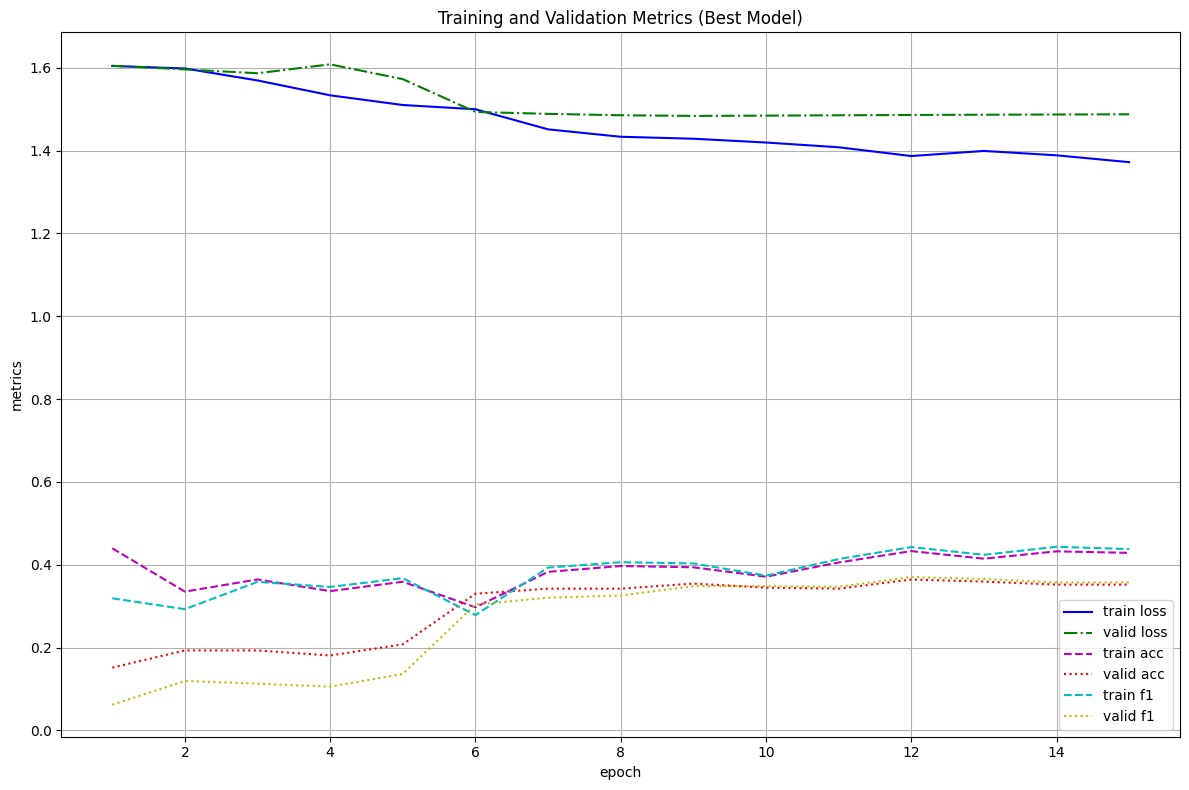

In [10]:

if hasattr(net, 'history_') and net.history_ is not None:
    # Print available metrics for debugging
    print("Available metrics:", net.history_[0].keys())
    
    epochs = list(range(1, len(net.history_) + 1))
    
    # Extract available metrics
    train_loss = [h.get('train_loss', None) for h in net.history_]
    valid_loss = [h.get('valid_loss', None) for h in net.history_]
    train_acc = [h.get('train_acc', None) for h in net.history_]
    valid_acc = [h.get('valid_acc', None) for h in net.history_]
    train_f1 = [h.get('train_f1', None) for h in net.history_]
    valid_f1 = [h.get('valid_f1', None) for h in net.history_]
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    plt.grid(True)
    
    # Plot metrics that exist
    if not all(x is None for x in train_loss):
        plt.plot(epochs, train_loss, 'b-', label='train loss')
    if not all(x is None for x in valid_loss):
        plt.plot(epochs, valid_loss, 'g-.', label='valid loss')
    if not all(x is None for x in train_acc):
        plt.plot(epochs, train_acc, 'm--', label='train acc')
    if not all(x is None for x in valid_acc):
        plt.plot(epochs, valid_acc, 'r:', label='valid acc')
    if not all(x is None for x in train_f1):
        plt.plot(epochs, train_f1, 'c--', label='train f1')
    if not all(x is None for x in valid_f1):
        plt.plot(epochs, valid_f1, 'y:', label='valid f1')
    
    plt.xlabel('epoch')
    plt.ylabel('metrics')
    plt.title('Training and Validation Metrics (Best Model)')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
else:
    print("Model history not found in the best estimator.")
    
    # If you want to see what's available
    if hasattr(net, 'history_'):
        print("History exists but might be empty or formatted differently.")
    else:
        print("No history_ attribute found on the best model.")

## Evaluation

In [11]:
preds = net.predict(X_test.astype(np.float32))
probs = net.predict_proba(X_test.astype(np.float32))

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='weighted')
report = classification_report(y_test, preds, target_names=label_encoder.classes_, digits=4)

print(f"Combined FFNN (GloVe) Accuracy: {acc * 100:.2f}%")
print(f"Combined FFNN (GloVe) Weighted F1-score: {f1:.4f}")
print("\nCombined FFNN (GloVe) Classification Report:\n", report)

Combined FFNN (GloVe) Accuracy: 33.59%
Combined FFNN (GloVe) Weighted F1-score: 0.3611

Combined FFNN (GloVe) Classification Report:
               precision    recall  f1-score   support

      center     0.2626    0.3562    0.3023        73
   lean left     0.2973    0.2716    0.2839        81
  lean right     0.1739    0.2609    0.2087        46
        left     0.7094    0.3689    0.4854       225
       right     0.1895    0.3333    0.2417        87

    accuracy                         0.3359       512
   macro avg     0.3266    0.3182    0.3044       512
weighted avg     0.4441    0.3359    0.3611       512



#### Classification Report Commentary

Accuracy increased negligibly from 0.3227 to 0.3359 and weighted f1 rose from 0.3372 to 0.3611. The augmentation of data only produced marginal improvements for the ill designed model. 

### Confusion Matrices

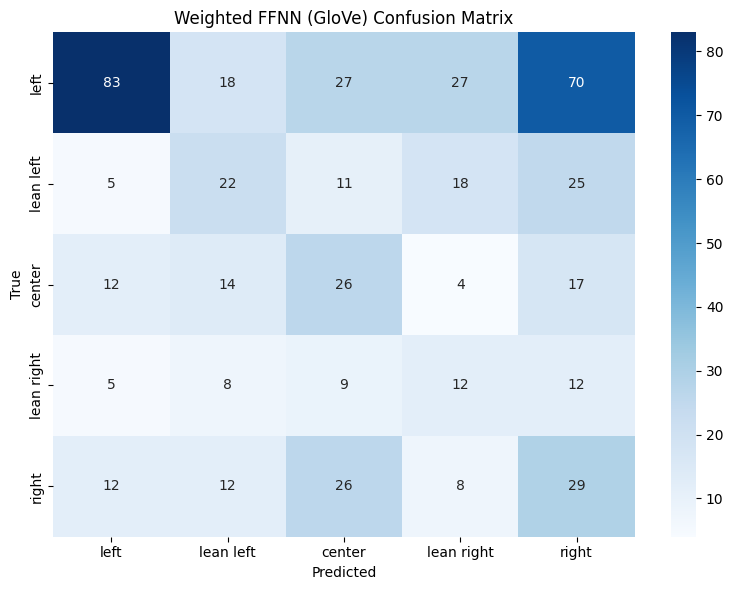

In [12]:
label_order = ['left', 'lean left', 'center', 'lean right', 'right']
label_indices = [np.where(label_encoder.classes_ == label)[0][0] for label in label_order]

#cm = confusion_matrix(y_test_np, y_pred, labels=label_indices)
cm = confusion_matrix(y_test, preds, labels=label_indices)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_order, yticklabels=label_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Weighted FFNN (GloVe) Confusion Matrix')
plt.tight_layout()
plt.show()

### ROC-AUC

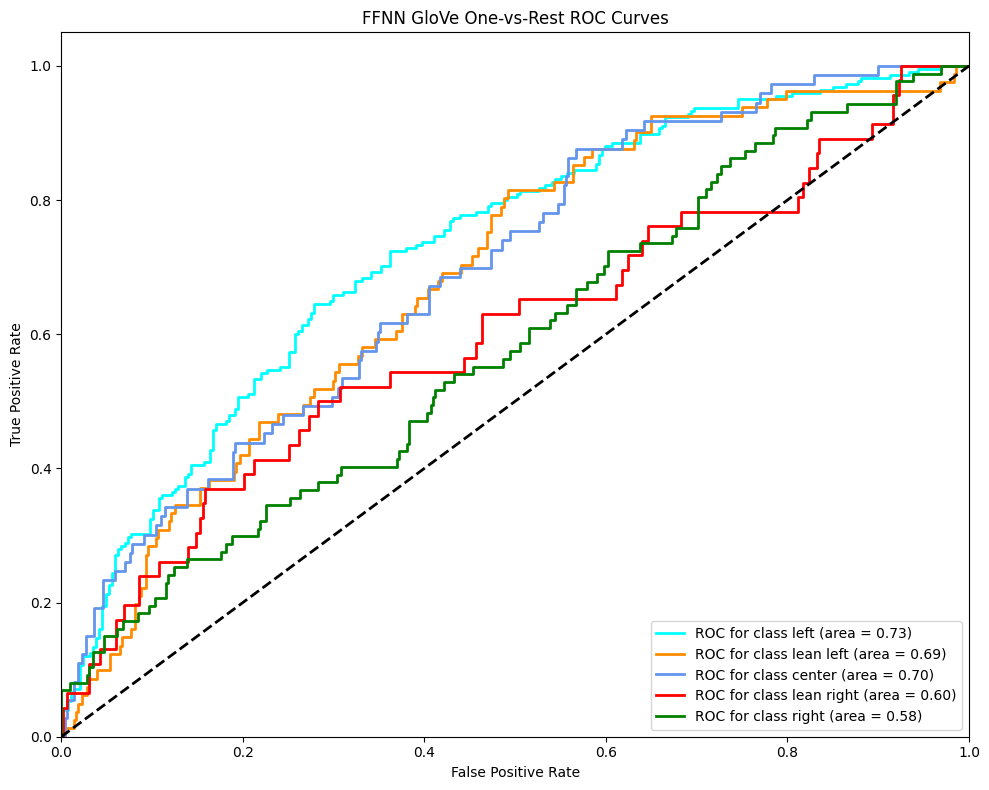

In [13]:
# ROC Curves
y_test_bin = label_binarize(y_test, classes=np.arange(output_dim))
probs = np.array(probs)
fpr = dict()
tpr = dict()
roc_auc = dict()

for label, idx in zip(label_order, label_indices):
    fpr[label], tpr[label], _ = roc_curve(y_test_bin[:, idx], probs[:, idx])
    roc_auc[label] = roc_auc_score(y_test_bin[:, idx], probs[:, idx])

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown'])

for label, color in zip(label_order, colors):
    plt.plot(fpr[label], tpr[label], color=color, lw=2,
             label=f'ROC for class {label} (area = {roc_auc[label]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('FFNN GloVe One-vs-Rest ROC Curves')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

There is a significant decline in the performance of class seperability noticed in the ROC-AUC curves.

In [14]:
macro_auc = roc_auc_score(y_test_bin, probs, average='weighted')
print(f"Macro-weighted ROC AUC: {macro_auc:.4f}")

Macro-weighted ROC AUC: 0.6819


Macro weighted ROC AUC also fell from 0.7095 to 0.6819, in line with the degregation of performance seen the ROC AUC curves.

## Final Conclusion

### Key Observations

As expected, there was only a marginal improvement to the performance of FFNN with GloVe. This is as the model is fundamentally unsuited to using GloVe. Averaging out the word embeddings dilutes the important signals. It would require strong inherent differientials in the vocabulary used by each bias to predict well. From our EDA, we knew that is not that case. 